**-> Persistence in Langgraph refers to the ability to save and restore the state of a workflow over time .**
**-> It stores intermediate values also.**
**-> It brings Fault Tolerence as we can start from the node after which crash had happend.**
**-> persistence in langgraph is implemented using checkpointers at every superstep.**
**-> Benifits of Persistence: Short term memory, Hitl(Human in the loop),fault tolerance,Time travel**



In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI 
import time

In [2]:
load_dotenv()
model=ChatGoogleGenerativeAI(model='gemini-2.5-flash')

In [3]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [4]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = model.invoke(prompt).content

    return {'joke': response}

In [5]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = model.invoke(prompt).content

    return {'explanation': response}

In [6]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

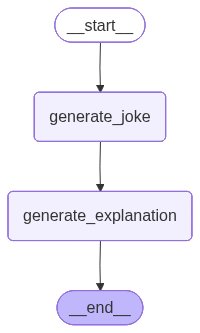

In [7]:
workflow

In [8]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a loan?\n\nBecause it **kneaded** the dough!',
 'explanation': 'This is a classic pun! The humor comes from the play on words, specifically with "kneaded" and "dough."\n\nHere\'s the breakdown:\n\n1.  **"Kneaded" (the action):** When you make pizza (or bread), you physically **knead** the **dough**. This is the process of working the mixture of flour, water, and other ingredients to develop gluten and create the right texture. This is a very literal, pizza-making term.\n\n2.  **"Needed" (the necessity):** The word "kneaded" sounds exactly like **"needed"** (the past tense of "to need").\n\n3.  **"Dough" (the food):** As mentioned, "dough" is the raw mixture used to make pizza.\n\n4.  **"Dough" (the money):** "Dough" is also a common slang term for **money**. (e.g., "I need some dough," "He\'s got a lot of dough.")\n\n**So, the joke works because:**\n\n*   The pizza *literally* "kneaded the dough" (the food item) as part of its ex

In [9]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a loan?\n\nBecause it **kneaded** the dough!', 'explanation': 'This is a classic pun! The humor comes from the play on words, specifically with "kneaded" and "dough."\n\nHere\'s the breakdown:\n\n1.  **"Kneaded" (the action):** When you make pizza (or bread), you physically **knead** the **dough**. This is the process of working the mixture of flour, water, and other ingredients to develop gluten and create the right texture. This is a very literal, pizza-making term.\n\n2.  **"Needed" (the necessity):** The word "kneaded" sounds exactly like **"needed"** (the past tense of "to need").\n\n3.  **"Dough" (the food):** As mentioned, "dough" is the raw mixture used to make pizza.\n\n4.  **"Dough" (the money):** "Dough" is also a common slang term for **money**. (e.g., "I need some dough," "He\'s got a lot of dough.")\n\n**So, the joke works because:**\n\n*   The pizza *literally* "kneaded the dough" (the food item

In [10]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a loan?\n\nBecause it **kneaded** the dough!', 'explanation': 'This is a classic pun! The humor comes from the play on words, specifically with "kneaded" and "dough."\n\nHere\'s the breakdown:\n\n1.  **"Kneaded" (the action):** When you make pizza (or bread), you physically **knead** the **dough**. This is the process of working the mixture of flour, water, and other ingredients to develop gluten and create the right texture. This is a very literal, pizza-making term.\n\n2.  **"Needed" (the necessity):** The word "kneaded" sounds exactly like **"needed"** (the past tense of "to need").\n\n3.  **"Dough" (the food):** As mentioned, "dough" is the raw mixture used to make pizza.\n\n4.  **"Dough" (the money):** "Dough" is also a common slang term for **money**. (e.g., "I need some dough," "He\'s got a lot of dough.")\n\n**So, the joke works because:**\n\n*   The pizza *literally* "kneaded the dough" (the food ite

In [11]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the pasta get arrested?\n\nBecause it was an **impasta**!',
 'explanation': 'This is a classic **pun**!\n\nThe joke plays on the similarity in sound between two words:\n\n1.  **Impasta (the word in the punchline):** This isn\'t a real word in the dictionary, but it\'s created for the joke by taking "pasta" and adding the "im-" prefix.\n2.  **Impostor (the word it sounds like):** An **impostor** is a person who pretends to be someone else in order to deceive or defraud. Impersonation and fraud are illegal activities, and an impostor would definitely get arrested for their actions.\n\n**The Joke\'s Connection:**\n\nThe humor comes from the fact that "impasta" sounds almost exactly like "impostor."\n\nSo, the joke is pretending that the pasta got arrested because it was "acting like an impostor" (being an "impasta"), which is a silly, non-literal reason for a food item to be arrested.\n\n**In short:** The pasta was an "impasta" (sounds like "impostor")

In [13]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta get arrested?\n\nBecause it was an **impasta**!', 'explanation': 'This is a classic **pun**!\n\nThe joke plays on the similarity in sound between two words:\n\n1.  **Impasta (the word in the punchline):** This isn\'t a real word in the dictionary, but it\'s created for the joke by taking "pasta" and adding the "im-" prefix.\n2.  **Impostor (the word it sounds like):** An **impostor** is a person who pretends to be someone else in order to deceive or defraud. Impersonation and fraud are illegal activities, and an impostor would definitely get arrested for their actions.\n\n**The Joke\'s Connection:**\n\nThe humor comes from the fact that "impasta" sounds almost exactly like "impostor."\n\nSo, the joke is pretending that the pasta got arrested because it was "acting like an impostor" (being an "impasta"), which is a silly, non-literal reason for a food item to be arrested.\n\n**In short:** The pasta was an "impasta" (soun

In [14]:
list(workflow.get_state_history(config=config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta get arrested?\n\nBecause it was an **impasta**!', 'explanation': 'This is a classic **pun**!\n\nThe joke plays on the similarity in sound between two words:\n\n1.  **Impasta (the word in the punchline):** This isn\'t a real word in the dictionary, but it\'s created for the joke by taking "pasta" and adding the "im-" prefix.\n2.  **Impostor (the word it sounds like):** An **impostor** is a person who pretends to be someone else in order to deceive or defraud. Impersonation and fraud are illegal activities, and an impostor would definitely get arrested for their actions.\n\n**The Joke\'s Connection:**\n\nThe humor comes from the fact that "impasta" sounds almost exactly like "impostor."\n\nSo, the joke is pretending that the pasta got arrested because it was "acting like an impostor" (being an "impasta"), which is a silly, non-literal reason for a food item to be arrested.\n\n**In short:** The pasta was an "impasta" (sou

### Time Travel

Here give the checkpoint_id for the node you want to see what checkpoints contain

In [15]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f15786e-22d9-6b77-8001-2de6e19c57f1"}})

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a loan?\n\nBecause it **kneaded** the dough!'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f15786e-22d9-6b77-8001-2de6e19c57f1'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-24T15:40:25.706994+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f15786d-ed61-676e-8000-63a46d81f7b8'}}, tasks=(PregelTask(id='856cc037-b81c-3d0e-7d5f-ed76e4212633', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result={'explanation': 'This is a classic pun! The humor comes from the play on words, specifically with "kneaded" and "dough."\n\nHere\'s the breakdown:\n\n1.  **"Kneaded" (the action):** When you make pizza (or bread), you physically **knead** the **dough**. This is the process of working the mixture of flour, water, and other i

You can start the workflow again from the given checkpoint using it's id

In [16]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f15786e-22d9-6b77-8001-2de6e19c57f1"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a loan?\n\nBecause it **kneaded** the dough!',
 'explanation': 'This joke is a classic pun that plays on two words that sound alike but have different meanings, and also uses a word with two different meanings.\n\nHere\'s the breakdown:\n\n1.  **"Kneaded" vs. "Needed":**\n    *   **Kneaded (pronounced "need-ed"):** This is what you literally do to pizza dough (work it with your hands) to prepare it for baking.\n    *   **Needed (pronounced "need-ed"):** This is the past tense of "to need." If you apply for a loan, it\'s because you *needed* money.\n\n2.  **"Dough":**\n    *   **Dough (literal):** The mixture of flour, water, etc., that you knead to make pizza.\n    *   **Dough (slang):** A common informal term for money.\n\n**Putting it all together:**\n\nThe joke works because:\n*   The pizza (or the person making it) literally **kneads** its own **dough** (the food ingredient).\n*   This sounds exactly like "it **needed** the *

In [17]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a loan?\n\nBecause it **kneaded** the dough!', 'explanation': 'This joke is a classic pun that plays on two words that sound alike but have different meanings, and also uses a word with two different meanings.\n\nHere\'s the breakdown:\n\n1.  **"Kneaded" vs. "Needed":**\n    *   **Kneaded (pronounced "need-ed"):** This is what you literally do to pizza dough (work it with your hands) to prepare it for baking.\n    *   **Needed (pronounced "need-ed"):** This is the past tense of "to need." If you apply for a loan, it\'s because you *needed* money.\n\n2.  **"Dough":**\n    *   **Dough (literal):** The mixture of flour, water, etc., that you knead to make pizza.\n    *   **Dough (slang):** A common informal term for money.\n\n**Putting it all together:**\n\nThe joke works because:\n*   The pizza (or the person making it) literally **kneads** its own **dough** (the food ingredient).\n*   This sounds exactly like 

### Updating State

In [18]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f15786d-ed61-676e-8000-63a46d81f7b8", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f157893-f688-6204-8001-fd82ad70aa8d'}}

In [19]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f157893-f688-6204-8001-fd82ad70aa8d'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-05-24T15:57:21.114573+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f15786d-ed61-676e-8000-63a46d81f7b8'}}, tasks=(PregelTask(id='c2b5d616-1e4a-dfb9-edf0-b6c5544f7f98', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a loan?\n\nBecause it **kneaded** the dough!', 'explanation': 'This joke is a classic pun that plays on two words that sound alike but have different meanings, and also uses a word with two different meanings.\n\nHere\'s the breakdown:\n\n1.  **"Kneaded" vs. "Needed":**\n    *   **Kneaded (pronounced 

In [20]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f157893-f688-6204-8001-fd82ad70aa8d"}})

{'topic': 'samosa',
 'joke': "Why don't samosas ever tell secrets?\n\nBecause they're afraid of **spilling the beans** (or potatoes)!",
 'explanation': 'This joke is a classic pun that plays on the double meaning of the phrase "spilling the beans."\n\nHere\'s the breakdown:\n\n1.  **The Idiom:** "Spilling the beans" is a common English idiom that means to **accidentally or prematurely reveal a secret or confidential information.**\n\n2.  **The Samosa Connection:** Samosas are delicious pastry pockets typically filled with savory ingredients like spiced potatoes, peas, and sometimes lentils or even **beans**.\n\n3.  **The Punchline\'s Twist:** The humor comes from applying the idiom to a samosa in a literal way.\n    *   If a samosa were to "spill its beans," it would literally mean its **filling** (the beans, potatoes, peas, etc.) would fall out.\n\nSo, the joke personifies the samosa, giving it a human-like fear of revealing secrets (the idiomatic meaning), but then delivers the punch

In [21]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': "Why don't samosas ever tell secrets?\n\nBecause they're afraid of **spilling the beans** (or potatoes)!", 'explanation': 'This joke is a classic pun that plays on the double meaning of the phrase "spilling the beans."\n\nHere\'s the breakdown:\n\n1.  **The Idiom:** "Spilling the beans" is a common English idiom that means to **accidentally or prematurely reveal a secret or confidential information.**\n\n2.  **The Samosa Connection:** Samosas are delicious pastry pockets typically filled with savory ingredients like spiced potatoes, peas, and sometimes lentils or even **beans**.\n\n3.  **The Punchline\'s Twist:** The humor comes from applying the idiom to a samosa in a literal way.\n    *   If a samosa were to "spill its beans," it would literally mean its **filling** (the beans, potatoes, peas, etc.) would fall out.\n\nSo, the joke personifies the samosa, giving it a human-like fear of revealing secrets (the idiomatic meaning), but the